Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

--- Analyzing EDEMA Habitat ---
✅ SVM AUC: 0.653
✅ RF AUC: 0.575
✅ XGB AUC: 0.595

--- Analyzing CORE Habitat ---
✅ SVM AUC: 0.608
✅ RF AUC: 0.585
✅ XGB AUC: 0.505


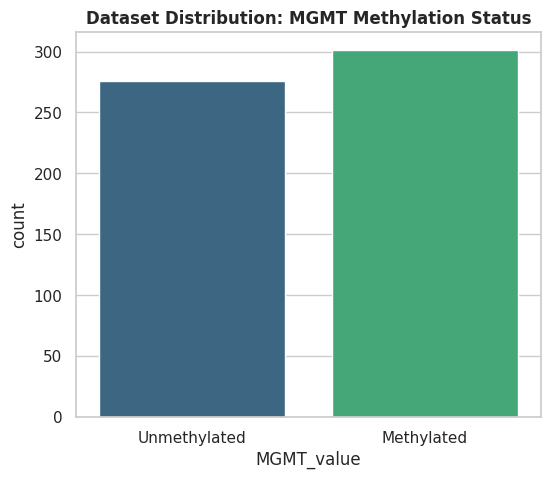

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

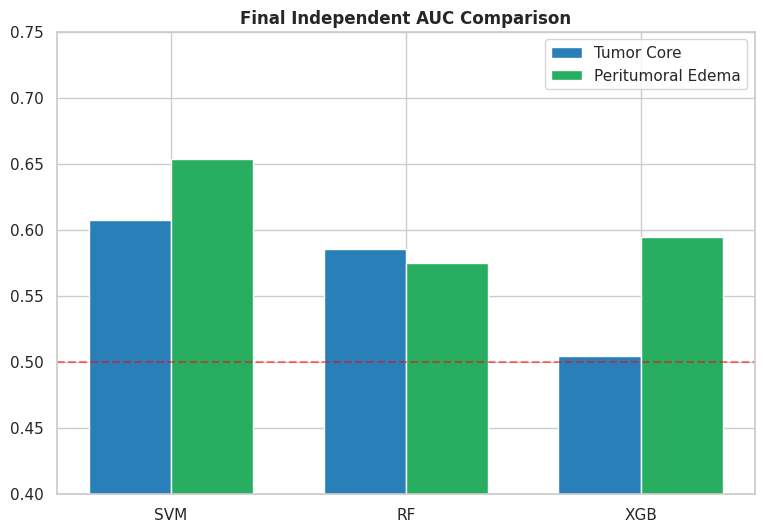

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

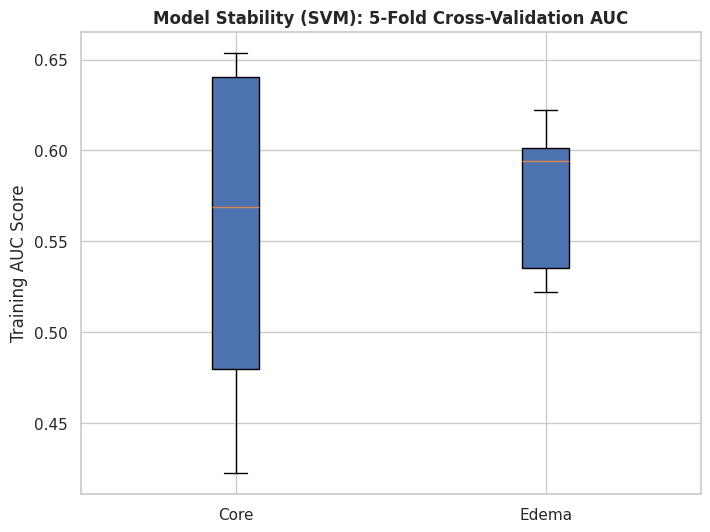

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

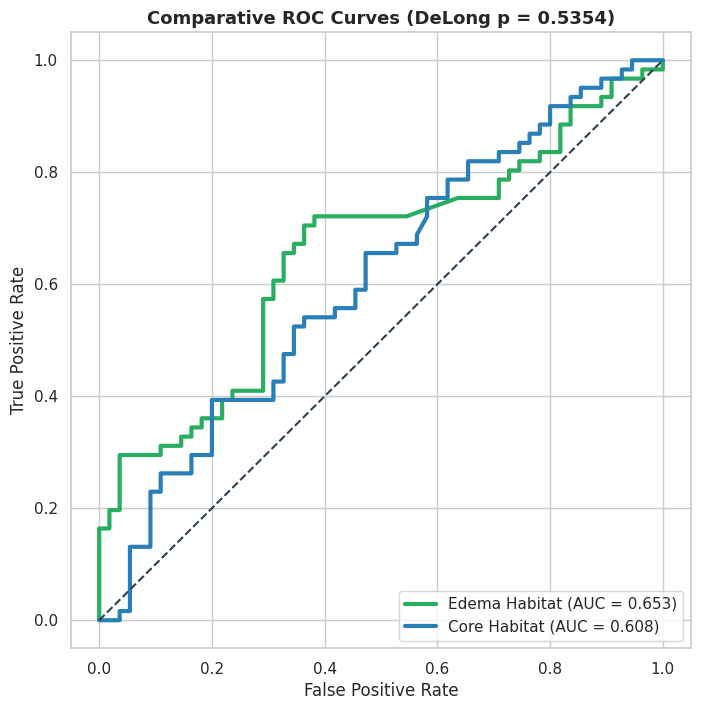

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

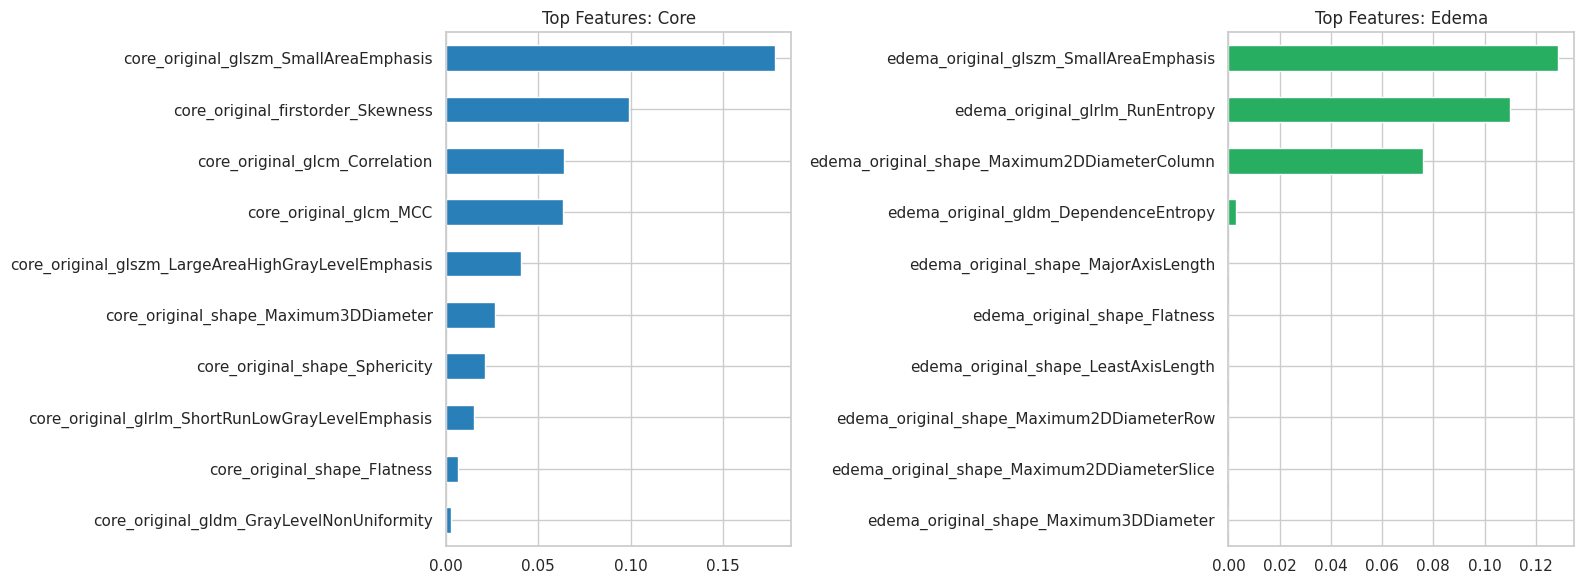

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

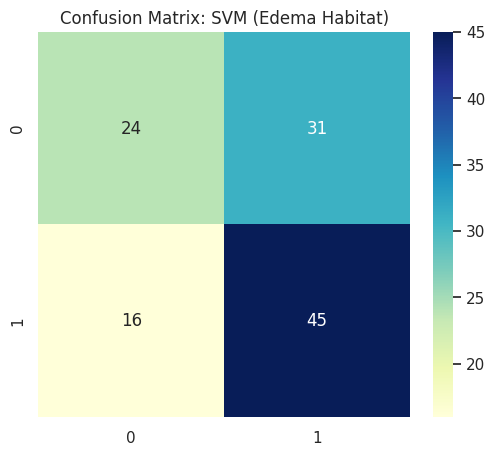

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🏆 Statistical Result: SVM Habitat Comparison p-value = 0.5354


In [7]:
# ==============================================================================
# MGMT PREDICTION: FULL PIPELINE WITH DELONG STATISTICAL COMPARISON
# Methodology: LASSO, 5-Fold CV, SVM/RF/XGB Benchmark & DeLong Test
# Author: Rafael Boava Souza, MD
# ==============================================================================

# 1. SETUP & IMPORTS
from google.colab import drive, files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import scipy.stats as stats
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix

warnings.filterwarnings('ignore')
drive.mount('/content/drive')

# Load Data
path_master = '/content/drive/MyDrive/Projeto_BraTS_Radiomica/base_treinamento_final.csv'
df = pd.read_csv(path_master)

X = df.drop(columns=['ID', 'MGMT_value'])
y = df['MGMT_value'].astype(int)

edema_features = [col for col in X.columns if 'edema' in col.lower() or 'flair' in col.lower()]
core_features = [col for col in X.columns if 'core' in col.lower() or 't1gd' in col.lower()]

# 2. DELONG TEST IMPLEMENTATION (MATHEMATICAL CORE)
def delong_roc_variance(ground_truth, predictions):
    m = np.sum(ground_truth == 1)
    n = np.sum(ground_truth == 0)
    pos_probs = predictions[ground_truth == 1]
    neg_probs = predictions[ground_truth == 0]
    v10 = np.zeros(m)
    v01 = np.zeros(n)
    for i in range(m):
        v10[i] = np.sum(neg_probs < pos_probs[i]) + 0.5 * np.sum(neg_probs == pos_probs[i])
    for j in range(n):
        v01[j] = np.sum(pos_probs > neg_probs[j]) + 0.5 * np.sum(pos_probs == neg_probs[j])
    v10 /= n
    v01 = (m - v01) / m
    return (np.var(v10, ddof=1) / m) + (np.var(v01, ddof=1) / n)

def delong_p_value(y_true, prob_a, prob_b):
    auc_a = roc_auc_score(y_true, prob_a)
    auc_b = roc_auc_score(y_true, prob_b)
    var_a = delong_roc_variance(y_true, prob_a)
    var_b = delong_roc_variance(y_true, prob_b)
    z = (auc_a - auc_b) / np.sqrt(var_a + var_b + 1e-10)
    return 2 * (1 - stats.norm.cdf(np.abs(z)))

# 3. ANALYTICAL FUNCTION
def run_benchmark_analysis(X_habitat, y_data, habitat_name):
    print(f"\n--- Analyzing {habitat_name} Habitat ---")
    X_train, X_test, y_train, y_test = train_test_split(X_habitat, y_data, test_size=0.2, random_state=42, stratify=y_data)

    scaler_l = StandardScaler()
    X_train_s = scaler_l.fit_transform(X_train)
    lasso = LogisticRegression(penalty='l1', solver='liblinear', C=0.1, random_state=42)
    lasso.fit(X_train_s, y_train)
    selected_feats = pd.Series(lasso.coef_[0], index=X_habitat.columns).abs().sort_values(ascending=False).head(10).index.tolist()

    X_tr_f, X_ts_f = X_train[selected_feats], X_test[selected_feats]
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    models = {
        'SVM': (SVC(probability=True, random_state=42), {'model__C': [1, 10], 'model__gamma': ['scale']}),
        'RF': (RandomForestClassifier(random_state=42), {'model__n_estimators': [100], 'model__max_depth': [10]}),
        'XGB': (XGBClassifier(eval_metric='logloss', random_state=42), {'model__learning_rate': [0.1], 'model__n_estimators': [100]})
    }

    results = {}
    for name, (model, params) in models.items():
        pipe = Pipeline([('scaler', StandardScaler()), ('model', model)])
        grid = GridSearchCV(pipe, params, cv=cv, scoring='roc_auc', n_jobs=-1)
        grid.fit(X_tr_f, y_train)
        probs = grid.best_estimator_.predict_proba(X_ts_f)[:, 1]
        cv_scores = cross_val_score(grid.best_estimator_, X_tr_f, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
        results[name] = {'auc': roc_auc_score(y_test, probs), 'probs': probs, 'y_test': y_test, 'cv_scores': cv_scores, 'model': grid.best_estimator_, 'X_test': X_ts_f}
        print(f"✅ {name} AUC: {results[name]['auc']:.3f}")

    return results, selected_feats, pd.Series(lasso.coef_[0], index=X_habitat.columns)[selected_feats]

# 4. EXECUTION
res_edema, feats_ed, coefs_ed = run_benchmark_analysis(X[edema_features], y, "EDEMA")
res_core, feats_co, coefs_co = run_benchmark_analysis(X[core_features], y, "CORE")

# 5. ALL VISUALIZATIONS (IN ENGLISH)

# PLOT 1: DATASET DISTRIBUTION
plt.figure(figsize=(6, 5))
sns.countplot(x=y, palette='viridis')
plt.title('Dataset Distribution: MGMT Methylation Status', fontweight='bold')
plt.xticks([0, 1], ['Unmethylated', 'Methylated'])
plt.savefig('dataset_distribution.png', dpi=300); plt.show(); files.download('dataset_distribution.png')

# PLOT 2: FINAL INDEPENDENT AUC COMPARISON
plt.figure(figsize=(9, 6))
labels = ['SVM', 'RF', 'XGB']
co_aucs = [res_core[m]['auc'] for m in labels]
ed_aucs = [res_edema[m]['auc'] for m in labels]
x = np.arange(len(labels)); width = 0.35
plt.bar(x - width/2, co_aucs, width, label='Tumor Core', color='#2980b9')
plt.bar(x + width/2, ed_aucs, width, label='Peritumoral Edema', color='#27ae60')
plt.axhline(y=0.5, color='red', ls='--', alpha=0.5); plt.ylim(0.4, 0.75)
plt.title('Final Independent AUC Comparison', fontweight='bold'); plt.xticks(x, labels); plt.legend()
plt.savefig('auc_comparison_bar.png', dpi=300); plt.show(); files.download('auc_comparison_bar.png')

# PLOT 3: MODEL STABILITY (BOXPLOT)
plt.figure(figsize=(8, 6))
plt.boxplot([res_core['SVM']['cv_scores'], res_edema['SVM']['cv_scores']], patch_artist=True, labels=['Core', 'Edema'])
plt.title('Model Stability (SVM): 5-Fold Cross-Validation AUC', fontweight='bold')
plt.ylabel('Training AUC Score')
plt.savefig('model_stability_boxplot.png', dpi=300); plt.show(); files.download('model_stability_boxplot.png')

# PLOT 4: COMPARATIVE ROC WITH DELONG P-VALUE
p_val = delong_p_value(res_edema['SVM']['y_test'], res_edema['SVM']['probs'], res_core['SVM']['probs'])
plt.figure(figsize=(8, 8))
fpr_e, tpr_e, _ = roc_curve(res_edema['SVM']['y_test'], res_edema['SVM']['probs'])
fpr_c, tpr_c, _ = roc_curve(res_core['SVM']['y_test'], res_core['SVM']['probs'])
plt.plot(fpr_e, tpr_e, color='#27ae60', lw=3, label=f'Edema Habitat (AUC = {res_edema["SVM"]["auc"]:.3f})')
plt.plot(fpr_c, tpr_c, color='#2980b9', lw=3, label=f'Core Habitat (AUC = {res_core["SVM"]["auc"]:.3f})')
plt.plot([0, 1], [0, 1], color='#2c3e50', linestyle='--')
plt.title(f'Comparative ROC Curves (DeLong p = {p_val:.4f})', fontsize=13, fontweight='bold')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.legend(loc='lower right')
plt.savefig('comparative_roc_curve.png', dpi=300); plt.show(); files.download('comparative_roc_curve.png')

# PLOT 5: LASSO FEATURE IMPORTANCE
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
coefs_co.abs().sort_values().plot(kind='barh', ax=ax1, color='#2980b9'); ax1.set_title('Top Features: Core')
coefs_ed.abs().sort_values().plot(kind='barh', ax=ax2, color='#27ae60'); ax2.set_title('Top Features: Edema')
plt.tight_layout(); plt.savefig('lasso_feature_importance.png', dpi=300); plt.show(); files.download('lasso_feature_importance.png')

# PLOT 6: CONFUSION MATRIX
best_h = "Core" if res_core['SVM']['auc'] > res_edema['SVM']['auc'] else "Edema"
best_res = res_core['SVM'] if best_h == "Core" else res_edema['SVM']
cm = confusion_matrix(best_res['y_test'], best_res['model'].predict(best_res['X_test']))
plt.figure(figsize=(6, 5)); sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu')
plt.title(f'Confusion Matrix: SVM ({best_h} Habitat)'); plt.savefig('confusion_matrix_final.png', dpi=300); plt.show(); files.download('confusion_matrix_final.png')

print(f"\n🏆 Statistical Result: SVM Habitat Comparison p-value = {p_val:.4f}")